### Build a basic chatbot with Langgraph (GRAPH API)

In [57]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [58]:
class State(TypedDict) :
    # messages have the type "list". the "add_messages" function
    # int the annotated defines how this state key should be updated
    # (in this case, it appends messages to the list, rather then overwritting them)
    messages: Annotated[list, add_messages]

In [59]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [60]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

model = "llama-3.1-8b-instant"

In [61]:
llm = ChatGroq(model=model)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002067E75DA70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002067E75D220>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [62]:
# another way
llm = init_chat_model(f"groq:{model}")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002067E236330>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002067E77C830>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [63]:
# Node Functionality
def chatbot(state:State) :
    return {"messages": [llm.invoke(state["messages"])]}

In [64]:
graph_builder = StateGraph(State)

# add node
graph_builder.add_node("llmchatbot", chatbot)

# add edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()

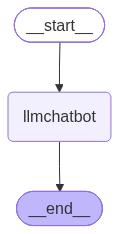

In [65]:
# visualize the graph
from IPython.display import Image, display

png_data = graph.get_graph().draw_mermaid_png()

try:
    display(Image(data = png_data))
except Exception :
    pass

In [66]:
response = graph.invoke({"messages": "hii"})
print(response)

{'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='40b961bb-1ab5-45d4-8c99-af3f1d4bc8f6'), AIMessage(content='Hello. How are you today? Is there something I can help you with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 37, 'total_tokens': 54, 'completion_time': 0.024953312, 'completion_tokens_details': None, 'prompt_time': 0.00174974, 'prompt_tokens_details': None, 'queue_time': 0.054153885, 'total_time': 0.026703052}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffcc2-e066-76c0-b555-841789e48ac5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 17, 'total_tokens': 54})]}


In [67]:
print(response["messages"][-1].content)

Hello. How are you today? Is there something I can help you with?


In [68]:
for event in graph.stream({"messages": "Hi, How are you?"}) :
    for value in event.values() :
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? Is there something I can assist you with?


### ChatBot with tools

In [69]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_result = 2)

tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [70]:
# custom function
def multiply(a:int, b:int)->int:
    """ Multiply a and b
    Args:
        a (int): first int
        b (int): second int
    
    Returns:
        int: output int
    """
    return a*b

In [71]:
tools = [tool, multiply]

In [72]:
llm_with_tools = llm.bind_tools(tools)

In [73]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002067E236330>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002067E77C830>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [74]:
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# node defination
def tool_calling_llm(State: State) :
    return {"messages": [llm_with_tools.invoke(State["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

# compile
graph = builder.compile()


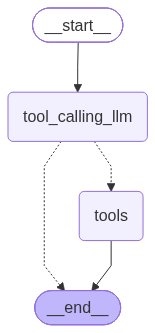

In [75]:
graph

In [76]:
msg = "what is the recent AI news"
response = graph.invoke({"messages": msg})

In [77]:
response["messages"][-1].content

'{"query": "AI news recent", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/08/13/ai-has-the-potential-for-harm-just-as-it-has-the-potential-for-good-says-richard-clarke.html", "title": "AI has the potential for harm just as it has the potential for good, says Richard Clarke - CNBC", "score": 0.7409441, "published_date": "Thu, 13 Aug 2026 12:12:46 GMT", "content": "# AI has the potential for harm just as it has the potential for good, says Richard Clarke. Richard Clarke, former White House counterterrorism coordinator, joins \'Squawk Box\' to discuss the recent AI cybersecurity breaches, the need for federal guardrails, and more. ECP’s Doug Kimmelman on AI data centers & power demand: This can be an enormous gift to the customer. Trump says Karoline Leavitt stepping down as Press Secretary. BofA Securities\' Aditya Bhave reaffirms Fed rate hike call. Bull market will run for the next few weeks, says Capital Area\'s Malcol

In [78]:
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (hhz33yq9a)
 Call ID: hhz33yq9a
  Args:
    query: AI news recent
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news recent", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/08/13/ai-has-the-potential-for-harm-just-as-it-has-the-potential-for-good-says-richard-clarke.html", "title": "AI has the potential for harm just as it has the potential for good, says Richard Clarke - CNBC", "score": 0.7409441, "published_date": "Thu, 13 Aug 2026 12:12:46 GMT", "content": "# AI has the potential for harm just as it has the potential for good, says Richard Clarke. Richard Clarke, former White House counterterrorism co

In [79]:
msg = "what is 2 multply by 3"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is 2 multply by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (4baynx91k)
 Call ID: 4baynx91k
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [81]:
msg = "what is the recent ai news and then multply 5 by 3"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and then multply 5 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (dyq13qqcp)
 Call ID: dyq13qqcp
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (g1e9jmz6p)
 Call ID: g1e9jmz6p
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/08/13/ai-has-the-potential-for-harm-just-as-it-has-the-potential-for-good-says-richard-clarke.html", "title": "AI has the potential for harm just as it has the potential for good, says Richard Clarke - CNBC", "score": 0.76300776, "published_date": "Thu, 13 Aug 2026 12:12:46 GMT", "content": "# AI has the potential for harm just as it has the p

### ReAct Agent Architecture

In [82]:
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# node defination
def tool_calling_llm(State: State) :
    return {"messages": [llm_with_tools.invoke(State["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# compile
graph = builder.compile()


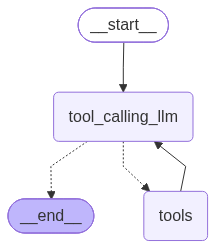

In [83]:
graph

In [84]:
msg = "what is the recent ai news and then multply 5 by 3"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and then multply 5 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fgcndxkhz)
 Call ID: fgcndxkhz
  Args:
    query: recent AI news
    time_range: day
    topic: general
  multiply (s4dd4b6j9)
 Call ID: s4dd4b6j9
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Akeneo introduced an agentic product experience platform to manage ecommerce product information. Autonomous AI agents write product descriptions, translate attributes across languages, and correct data inconsistencies.\n\nAltudo re

### Adding Memory in Agentic Graph

In [85]:
msg = "Hello, My name is Gourab Das"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hello, My name is Gourab Das
================================== Ai Message ==================================

Nice to meet you, Gourab Das! How can I assist you today?


In [86]:
msg = "what is my name?"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Unfortunately, I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or access external data about you. Each time you interact with me, it's a new conversation and I don't retain any context from previous conversations. If you'd like to share your name with me, I can chat with you about it!


In [89]:
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# node defination
def tool_calling_llm(State: State) :
    return {"messages": [llm_with_tools.invoke(State["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# compile
graph = builder.compile(checkpointer=memory) 

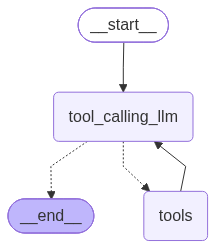

In [90]:
graph

In [91]:
config = {"configurable": {"thread_id": "user1"}}
msg = "Hii, I am Gourab..."

response = graph.invoke({"messages":msg}, config=config)

for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hii, I am Gourab...
================================== Ai Message ==================================

Nice to meet you, Gourab. Is there something I can help you with today?


In [92]:
config = {"configurable": {"thread_id": "user1"}}
msg = "What is my name?"

response = graph.invoke({"messages":msg}, config=config)

for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hii, I am Gourab...
================================== Ai Message ==================================

Nice to meet you, Gourab. Is there something I can help you with today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Gourab.


In [94]:
config = {"configurable": {"thread_id": "user1"}}
msg = "what you know about me?"

response = graph.invoke({"messages":msg}, config=config)

for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hii, I am Gourab...
================================== Ai Message ==================================

Nice to meet you, Gourab. Is there something I can help you with today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Gourab.
================================ Human Message =================================

what you name of mine
================================== Ai Message ==================================

You're asking for my name. I don't have a personal name, but I'm an AI assistant, so you can call me "Assistant" or "AI" if you like.
================================ Human Message =================================

what you know about me?
================================== Ai Message ==================================

We've had a very short conversatio